# 1. Import and basic properties of dataset

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
sb.set()

all_data = pd.read_csv('cardio_train.csv',sep=';')
all_data.head(5)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [ ]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [ ]:
all_data.describe()

##Check if there are any null values

In [ ]:
print(all_data.isnull().sum())

# 2. Data Cleaning and Preparation

## Age Conversion (Days to Years)

In [ ]:
all_data = pd.read_csv('cardio_train.csv',sep=';')
all_data['age'] = all_data['age'] / 365.25
print(f"Maximum value of age: {all_data['age'].max():.2f}")
print(f"Minimum value of age: {all_data['age'].min():.2f}")

##Outlier Removal for ap_hi and ap_lo

1. Reason

- min for ap_hi and ap_lo are -150 and -70
- max for ap_hi and ap_lo are 16020 and 11000
- These data are medically inaccurate, therefore we have to remove these outliers

2. Method
- Set boundaries for ap_hi and ap_lo
- ap_hi $\in$ [60, 250]
- ap_lo $\in$ [40, 140]
- Or use IQR method

3. Other
- Systolic Pressure is always higher than Diastolic Pressure
- ap_hi > ap_lo

In [ ]:
# IQR method for ap_hi
Q1_hi = all_data['ap_hi'].quantile(0.25)
Q3_hi = all_data['ap_hi'].quantile(0.75)
IQR_hi = Q3_hi - Q1_hi

lower_hi = Q1_hi - 1.5 * IQR_hi
upper_hi = Q3_hi + 1.5 * IQR_hi
print(f"Lower bound for ap_hi: {lower_hi:.2f}")
print(f"Upper bound for ap_hi: {upper_hi:.2f}")

# IQR method for ap_lo
Q1_lo = all_data['ap_lo'].quantile(0.25)
Q3_lo = all_data['ap_lo'].quantile(0.75)
IQR_lo = Q3_lo - Q1_lo

lower_lo = Q1_lo - 1.5 * IQR_lo
upper_lo = Q3_lo + 1.5 * IQR_lo
print(f"Lower bound for ap_lo: {lower_lo:.2f}")
print(f"Upper bound for ap_lo: {upper_lo:.2f}")



3. Analysis
- [90, 170] as domain for ap_hi and [65, 105] for ap_lo might exclude data that is relevant to predicting cardiovascular disease, causing a biased in conclusion
- Therefore we will use [60, 250] and [40, 140] as domains

In [ ]:
# Set_boundaries
all_data['ap_hi'] = all_data['ap_hi'].where(all_data['ap_hi'].between(60, 250), np.nan)
all_data['ap_lo'] = all_data['ap_lo'].where(all_data['ap_lo'].between(40, 140), np.nan)
clean_data = all_data.dropna(subset=['ap_hi', 'ap_lo'])

# Remove rows that have ap_hi < ap_lo
all_data = all_data[all_data['ap_hi'] > all_data['ap_lo']]

# Remaining rows
print(f"Rows remaining after outliers removal: {len(all_data)}")

## BMI = Mass(kg) / (Height(m))^2

In [ ]:
all_data['BMI'] = all_data['weight'] / (all_data['height'] / 100) ** 2
print(f"Maximum value of BMI: {all_data['BMI'].max():.2f}")
print(f"Minimum value of BMI: {all_data['BMI'].min():.2f}")


## Outlier Removal for BMI
1. Reason
- 3.47 and 298.67 are unrealistic values for BMI according to medical data and theories.
- Therefore we have to remove these outliers
2. Method
- Set boundary for BMI
- BMI $\in$ [14, 60]
- Or use IQR method

In [ ]:
# IQR method
Q1 = all_data['BMI'].quantile(0.25)
Q3 = all_data['BMI'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(f"Lower bound for BMI: {lower:.2f}")
print(f"Upper bound BMI: {upper:.2f}")

2. Analysis
- Lowerbound 14.51 is medically sensible
- The upperbound would remove morbidly obese patients who have BMI > 39.49, who are relevant to cardiovascular risk.
- Therefore, we can use lowerbound = 14.51, but we have to raise the upper bound to 50 to avoid the data being biased.

In [ ]:
all_data = all_data[(all_data['BMI'] >= lower) & (all_data['BMI'] <= 50)]
print(f"Rows remaining: {len(all_data)}")

##Pulse Pressure: pulse_press = ap_hi - ap_lo

In [ ]:
all_data['pulse_press'] = all_data['ap_hi'] - all_data['ap_lo']
print(f"Maximum value of Pulse Pressure: {all_data['pulse_press'].max():.2f}")
print(f"Minimum value of Pulse Pressure: {all_data['pulse_press'].min():.2f}")

## Outliers Removal for Pulse Pressure
1. Reason
- Pulse Pressure below 25 mmHg is unlikely and associated with life-threatening conditions
- Therefore, we need to remove these outliers
2. Methods
- Set boundary
- pulse_press $\in$ [25, 140]
- Use IQR method

In [ ]:
# IQR method
Q1 = all_data['pulse_press'].quantile(0.25)
Q3 = all_data['pulse_press'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(f"Lower bound for Pulse Pressure: {lower:.2f}")
print(f"Upper bound Pulse Pressure: {upper:.2f}")

3. Analysis
- Lower bound = 25 is medically sensible
- Lower bound = 60 can exclude data that is relevant to predicting cardiovascular disease
- Therfore, we will use [25, 140] for pulse_press

In [ ]:
all_data = all_data[(all_data['pulse_press'] >= lower) & (all_data['pulse_press'] <= 140)]
print(f"Rows remaining: {len(all_data)}")

## Finalize dataset

In [ ]:
# Drop the columm 'id' and rearrange the columns
clean_data = all_data.copy()
clean_data = clean_data.drop(columns = ['id'])

right_order = ['age', 'gender', 'height', 'weight', 'BMI', 'ap_hi', 'ap_lo', 'pulse_press', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']
clean_data = clean_data[right_order]

In [ ]:
clean_data.info()

In [ ]:
clean_data.describe()

#3. Exploratory Data Analysis

In [ ]:
# Check if there are any null values
print(clean_data.isnull().sum())

In [ ]:
# Check the balance of variable 'cardio'
print(clean_data['cardio'].map({0: 'No CVD', 1: 'CVD'}).value_counts())
print()
print(f"The rate of people with no CVD is: {1 - clean_data['cardio'].sum() / len(clean_data):.4f}")
print(f"The rate of people with CVD is: {clean_data['cardio'].sum() / len(clean_data):.4f}")

The rate of people with no CVD is similar to the rate of the people with CVD shows that the dataset is balanced, the models when used will not be biased toward predicting the response variable.


###We will divide the features into 2 groups: **Clinical features** and **Lifestyle features**

### Question: Which features will be the best to predict CVD rate, do clinical or lifestyle features have more influence on the prediction, are there certain groups that significantly have more possibility to have CVD compare to others?

## Clinical features

In [ ]:
clinical_features = clean_data.drop(columns = ['smoke', 'alco', 'active'])


In [ ]:
clinical_features.info()

### A temporary datset for plotting

In [ ]:
# Temporary dataset for plotting
plot_data = clinical_features.copy()
plot_data['cardio'] = plot_data['cardio'].map({0: 'No CVD', 1: 'CVD'})
plot_data['gender'] = plot_data['gender'].map({1: 'Female', 2: 'Male'})
plot_data['cholesterol'] = plot_data['cholesterol'].map({
    1: 'Normal',
    2: 'Above Normal',
    3: 'Well Above Normal'
})
plot_data['gluc'] = plot_data['gluc'].map({
    1: 'Normal',
    2: 'Above Normal',
    3: 'Well Above Normal'
})


## Age

### Plotting Age against CVD status (Yes/No)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sb.histplot(data=plot_data, x='age', hue='cardio', bins=30, kde=True, ax=axes[0], palette={'No CVD': 'mediumseagreen', 'CVD': 'salmon'})
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution by CVD Status')

# Boxplot
sb.boxplot(data=plot_data, x='cardio', y='age', ax=axes[1])
axes[1].set_xlabel('Cardiovascular Disease')
axes[1].set_ylabel('Age (years)')
axes[1].set_title('Age vs Cardiovascular Disease')

plt.tight_layout()
plt.show()


### Analysis
The histogram and boxplot show that CVD patients tend to be older than non-CVD patients. The CVD distribution shifted noticeably to the right. The median age for CVD patients is visibly higher than for non-CVD patients. The evidence suggests age is a strong clinical predictor of cardiovascular disease.

## Height

### Plotting Height against CVD status (Yes/No)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sb.histplot(data=plot_data, x='height', hue='cardio', bins=30, kde=True, ax=axes[0], palette={'No CVD': 'mediumseagreen', 'CVD': 'salmon'})
axes[0].set_xlabel('Height')
axes[0].set_ylabel('Count')
axes[0].set_title('Height Distribution by CVD Status')

# Boxplot
sb.boxplot(data=plot_data, x='cardio', y='height', ax=axes[1])
axes[1].set_xlabel('Cardiovascular Disease')
axes[1].set_ylabel('height')
axes[1].set_title('Height vs Cardiovascular Disease')

plt.tight_layout()
plt.show()

### Analysis
The histogram and boxplot show very similar distributions between CVD and non-CVD patients for height. There are not many noticeable differences. This suggests Height alone is not a strong clinical predictor.

## Weight

### Plotting Weight against CVD status (Yes/No)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sb.histplot(data=plot_data, x='weight', hue='cardio', bins=30, kde=True, ax=axes[0], palette={'No CVD': 'mediumseagreen', 'CVD': 'salmon'})
axes[0].set_xlabel('Weight')
axes[0].set_ylabel('Count')
axes[0].set_title('Weight Distribution by CVD Status')

# Boxplot
sb.boxplot(data=plot_data, x='cardio', y='weight', ax=axes[1])
axes[1].set_xlabel('Cardiovascular Disease')
axes[1].set_ylabel('weight')
axes[1].set_title('Weight vs Cardiovascular Disease')

plt.tight_layout()
plt.show()

The histogram and boxplot show very similar distributions between CVD and non-CVD patients for weight. There are not many noticeable differences accept CVD patients usually weight a bit more than non-CVD patients in general. This suggests Weight alone is not a strong clinical predictor.

## BMI

### Plotting BMI against CVD status (Yes/ No)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sb.histplot(data = plot_data, x='BMI', hue='cardio', bins=30, kde=True, ax=axes[0], palette={'No CVD': 'mediumseagreen', 'CVD': 'salmon'})
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Count')
axes[0].set_title('BMI Distribution by CVD Status')

# Boxplot
sb.boxplot(data=plot_data, x='cardio', y='BMI', ax=axes[1])
axes[1].set_xlabel('Cardiovascular Disease')
axes[1].set_ylabel('BMI')
axes[1].set_title('BMI vs Cardiovascular Disease')

plt.tight_layout()
plt.show()

### Analysis
While histogram shows quite similar distribution between CVD and non_CVD patients for BMI. Box plot gives us more valuable information, with CVD patients in general have higher median and BMI values compared to non-CVD patients. This shows that while Height and Weight alone are not good predictor, BMI has certain affects on predicting CVD.

## Gender

### Plotting Gender against CVD status (Yes/No)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sb.countplot(data = plot_data, x = 'gender', hue = 'cardio',
             palette = {'No CVD': 'mediumseagreen', 'CVD': 'salmon'}, ax = axes[0])
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
axes[0].set_title('CVD Count by Gender')

# Rate plot
gender_rate = plot_data.groupby('gender')['cardio'].apply(
    lambda x: (x == 'CVD').mean() * 100).reset_index()
gender_rate.columns = ['gender', 'CVD Rate (%)']
gender_rate['No CVD Rate (%)'] = 100 - gender_rate['CVD Rate (%)']
print(gender_rate)
sb.barplot(data = gender_rate, x = 'gender', y = 'CVD Rate (%)', ax = axes[1],
           palette = {'Female': 'mediumseagreen', 'Male': 'salmon'})
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('CVD Rate (%)')
axes[1].set_title('CVD Rate by Gender')

plt.tight_layout()
plt.show()

### Analysis
The count plot and rate plot show similar data between CVD and non-CVD patients based on gender. There are no noticeable separation. This suggests gender is not a significant predictor for CVD.

## Systolic Blood Pressure

### Plotting Systolic Blood Pressure against CVD status (Yes/ No)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sb.histplot(data=plot_data, x='ap_hi', hue='cardio', bins=30, kde=True, ax=axes[0], palette={'No CVD': 'mediumseagreen', 'CVD': 'salmon'})
axes[0].set_xlabel('Systolic Blood Pressure')
axes[0].set_ylabel('Count')
axes[0].set_title('Systolic Blood Pressure Distribution by CVD Status')

# Boxplot
sb.boxplot(data=plot_data, x='cardio', y='ap_hi', ax=axes[1])
axes[1].set_xlabel('Cardiovascular Disease')
axes[1].set_ylabel('Systolic Blood Pressure')
axes[1].set_title('Systolic Blood Pressure vs Cardiovascular Disease')

plt.tight_layout()
plt.show()

### Analysis
Systolic blood pressure shows the clearest separation between CVD and non-CVD patients among all clinical features examined so far.
CVD patients consistently show higher systolic pressure. This confirms ap_hi as a strong clinical predictor.

## Diastolic Blood Pressure

### Plotting Diastolic Blood Pressure against CVD status (Yes/ No)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sb.histplot(data=plot_data, x='ap_lo', hue='cardio', bins=30, kde=True, ax=axes[0], palette={'No CVD': 'mediumseagreen', 'CVD': 'salmon'})
axes[0].set_xlabel('Diastolic Blood Pressure')
axes[0].set_ylabel('Count')
axes[0].set_title('Diastolic Blood Pressure Distribution by CVD Status')

# Boxplot
sb.boxplot(data=plot_data, x='cardio', y='ap_lo', ax=axes[1])
axes[1].set_xlabel('Cardiovascular Disease')
axes[1].set_ylabel('Diastolic Blood Pressure')
axes[1].set_title('Diastolic Blood Pressure vs Cardiovascular Disease')

plt.tight_layout()
plt.show()

### Analysis
Similar to systolic blood pressure, diastolic blood pressure shows clear separation between CVD and non-CVD patients. CVD patients consistently show higher diastolic pressure. This confirms ap_lo as a strong clinical predictor.

## Pulse Pressure

### Plotting Pulse Pressure against CVD status (Yes/ No)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sb.histplot(data=plot_data, x='pulse_press', hue='cardio', bins=30, kde=True, ax=axes[0], palette={'No CVD': 'mediumseagreen', 'CVD': 'salmon'})
axes[0].set_xlabel('Pulse Pressure')
axes[0].set_ylabel('Count')
axes[0].set_title('Pulse Pressure Distribution by CVD Status')

# Boxplot
sb.boxplot(data=plot_data, x='cardio', y='pulse_press', ax=axes[1])
axes[1].set_xlabel('Cardiovascular Disease')
axes[1].set_ylabel('Pulse Pressure')
axes[1].set_title('Pulse Pressure vs Cardiovascular Disease')

plt.tight_layout()
plt.show()

### Analysis
The histogram and box plot show interesting result, pulse pressure of most non-CVD patients are equal to 40, while CVD patients have a wider distribution. This is a really clear seperation. It confirms that Pulse Pressure is a strong clinical predictor.

## Cholesterol

Plotting Cholesterol Level against CVD Status (Yes/ No)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sb.countplot(data=plot_data, x='cholesterol', hue='cardio',
             order=['Normal', 'Above Normal', 'Well Above Normal'],
             palette={'No CVD': 'mediumseagreen', 'CVD': 'salmon'}, ax=axes[0])
axes[0].set_xlabel('Cholesterol Level')
axes[0].set_ylabel('Count')
axes[0].set_title('CVD Count by Cholesterol Level')

# Rate plot
chol_rate = plot_data.groupby('cholesterol')['cardio'].apply(
    lambda x: (x == 'CVD').mean() * 100).reset_index()

chol_rate.columns = ['cholesterol', 'CVD Rate (%)']
chol_rate['No CVD Rate (%)'] = 100 - chol_rate['CVD Rate (%)']
chol_rate['cholesterol'] = pd.Categorical(chol_rate['cholesterol'],
    categories=['Normal', 'Above Normal', 'Well Above Normal'], ordered=True)
chol_rate = chol_rate.sort_values('cholesterol')
print(chol_rate.to_string(float_format='%.2f'))
sb.barplot(data=chol_rate, x='cholesterol', y='CVD Rate (%)', ax=axes[1],
           palette='Reds')
axes[1].set_xlabel('Cholesterol Level')
axes[1].set_ylabel('CVD Rate (%)')
axes[1].set_title('CVD Rate by Cholesterol Level')

plt.tight_layout()
plt.show()

### Analysis
The graphs clearly show that the CVD rate significantly grows with the increase of cholesterol level. This suggests cholesterol level has a strong relationship with CVD risk.

## Glucose

Plotting Glucose Level against CVD Status (Yes/ No)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sb.countplot(data=plot_data, x='gluc', hue='cardio',
             order=['Normal', 'Above Normal', 'Well Above Normal'],
             palette={'No CVD': 'mediumseagreen', 'CVD': 'salmon'}, ax=axes[0])
axes[0].set_xlabel('Glucose Level')
axes[0].set_ylabel('Count')
axes[0].set_title('CVD Count by Glucose Level')

# Rate plot
gluc_rate = plot_data.groupby('gluc')['cardio'].apply(
    lambda x: (x == 'CVD').mean() * 100).reset_index()

gluc_rate.columns = ['gluc', 'CVD Rate (%)']
gluc_rate['No CVD Rate (%)'] = 100 - gluc_rate['CVD Rate (%)']
gluc_rate['gluc'] = pd.Categorical(gluc_rate['gluc'],
    categories=['Normal', 'Above Normal', 'Well Above Normal'], ordered=True)
gluc_rate = gluc_rate.sort_values('gluc')
print(chol_rate.to_string(float_format='%.2f'))
sb.barplot(data = gluc_rate, x='gluc', y='CVD Rate (%)', ax=axes[1],
           palette='Reds')
axes[1].set_xlabel('Glucose Level')
axes[1].set_ylabel('CVD Rate (%)')
axes[1].set_title('CVD Rate by Glucose Level')

plt.tight_layout()
plt.show()

The graphs show that CVD Rate consistently grows with the increase of Glucose Level, which suggests that Glucose is a moderate predictor.

## Lifestyle Features

In [ ]:
lifestyle_features = clean_data[['smoke', 'alco', 'active', 'cardio']]

In [ ]:
lifestyle_features.info()

In [ ]:
# Temporary dataset for plotting
plot_data = lifestyle_features.copy()
plot_data['cardio'] = plot_data['cardio'].map({0: 'No CVD', 1: 'CVD'})
plot_data['smoke'] = plot_data['smoke'].map({0: 'No Smoking', 1: 'Smoking'})
plot_data['alco'] = plot_data['alco'].map({0: 'No Drinking', 1: 'Drinking'})
plot_data['active'] = plot_data['active'].map({0: 'Inactive', 1: 'Active'})

## Smoke

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sb.countplot(data = plot_data, x = 'smoke', hue = 'cardio',
             palette = {'No CVD': 'mediumseagreen', 'CVD': 'salmon'}, ax = axes[0])
axes[0].set_xlabel('Smoke')
axes[0].set_ylabel('Count')
axes[0].set_title('CVD Count by Smoke')

# Rate plot
smoke_rate = plot_data.groupby('smoke')['cardio'].apply(
    lambda x: (x == 'CVD').mean() * 100).reset_index()
smoke_rate.columns = ['smoke', 'CVD Rate (%)']
smoke_rate['No CVD Rate (%)'] = 100 - smoke_rate['CVD Rate (%)']
print(smoke_rate)
sb.barplot(data = smoke_rate, x = 'smoke', y = 'CVD Rate (%)', ax = axes[1],
           palette = {'No Smoking': 'mediumseagreen', 'Smoking': 'salmon'})
axes[1].set_xlabel('Smoke')
axes[1].set_ylabel('CVD Rate (%)')
axes[1].set_title('CVD Rate by Smoke')

plt.tight_layout()
plt.show()

## Alcohol

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sb.countplot(data = plot_data, x = 'alco', hue = 'cardio',
             palette = {'No CVD': 'mediumseagreen', 'CVD': 'salmon'}, ax = axes[0])
axes[0].set_xlabel('Alcohol')
axes[0].set_ylabel('Count')
axes[0].set_title('CVD Count by Alcohol')

# Rate plot
alco_rate = plot_data.groupby('alco')['cardio'].apply(
    lambda x: (x == 'CVD').mean() * 100).reset_index()
alco_rate.columns = ['alco', 'CVD Rate (%)']
alco_rate['No CVD Rate (%)'] = 100 - alco_rate['CVD Rate (%)']
print(alco_rate)
sb.barplot(data = alco_rate, x = 'alco', y = 'CVD Rate (%)', ax = axes[1],
           palette = {'No Drinking': 'mediumseagreen', 'Drinking': 'salmon'})
axes[1].set_xlabel('Alcohol')
axes[1].set_ylabel('CVD Rate (%)')
axes[1].set_title('CVD Rate by Alcohol')

plt.tight_layout()
plt.show()

## Active

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sb.countplot(data = plot_data, x = 'active', hue = 'cardio',
             palette = {'No CVD': 'mediumseagreen', 'CVD': 'salmon'}, ax = axes[0])
axes[0].set_xlabel('Active')
axes[0].set_ylabel('Count')
axes[0].set_title('CVD Count by Active')

# Rate plot
active_rate = plot_data.groupby('active')['cardio'].apply(
    lambda x: (x == 'CVD').mean() * 100).reset_index()
active_rate.columns = ['active', 'CVD Rate (%)']
active_rate['No CVD Rate (%)'] = 100 - active_rate['CVD Rate (%)']
print(active_rate)
sb.barplot(data = active_rate, x = 'active', y = 'CVD Rate (%)', ax = axes[1],
           palette = {'Inactive': 'mediumseagreen', 'Active': 'salmon'})
axes[1].set_xlabel('Active')
axes[1].set_ylabel('CVD Rate (%)')
axes[1].set_title('CVD Rate by Active')

plt.tight_layout()
plt.show()

### Analysis for lifestyle features
Contrary to expectation, smoking and alcohol consumption show surprisingly weak association with CVD, with non-smokers and non-drinkers showing higher CVD rates. This counterintuitive result may reflect sampling bias in the dataset. Physical activity shows a slightly more expected pattern with inactive patients having marginally higher CVD rates.

### Further analysis for lifestyle features
We need to take a closer look why do this counter-intuitive relations happens. Let's take a look at the average age, the number count, and the rate of CVD of each lifestyle groups.

In [ ]:
# Prep: combine age, lifestyle factors and cardio into one DataFrame
age_lifestyle = pd.concat([
    all_data['age'],
    all_data['smoke'],
    all_data['alco'],
    all_data['active'],
    all_data['cardio']
], axis=1)
age_lifestyle.columns = ['age', 'smoke', 'alco', 'active', 'cardio']

# Create age bins
age_bins = ["30-35", "35-40", "40-45", "45-50", "50-55", "55-60", "60-65"]
age_lifestyle['age_bin'] = pd.cut(age_lifestyle['age'], bins=range(30, 70, 5), labels=age_bins)
print(age_lifestyle.head())

#Average age of each group
lifestyles = ['smoke', 'alco', 'active']
for lifestyle in lifestyles:
    age_no = age_lifestyle[age_lifestyle[lifestyle] == 0]['age'].mean()
    age_yes = age_lifestyle[age_lifestyle[lifestyle] == 1]['age'].mean()
    print(f"The average age for non-{lifestyle}: {age_no}, for {lifestyle}: {age_yes}")
# Value count for each age group engaging in certain activities
for age_bin in age_bins:
    bin_data = age_lifestyle[age_lifestyle['age_bin'] == age_bin]
    non_smokers = len(bin_data[bin_data['smoke'] == 0])
    smokers = len(bin_data[bin_data['smoke'] == 1])
    non_drinkers = len(bin_data[bin_data['alco'] == 0])
    drinkers = len(bin_data[bin_data['alco'] == 1])
    inactive = len(bin_data[bin_data['active'] == 0])
    active = len(bin_data[bin_data['active'] == 1])
    print(f"For the {age_bin} group:")
    print(f"  Smokers: {smokers}, Non-smokers: {non_smokers}")
    print(f"  Drinkers: {drinkers}, Non-drinkers: {non_drinkers}")
    print(f"  Active: {active}, Inactive: {inactive}")
# For each lifestyle factor, calculate CVD rate per age bin (split by group)
lifestyle_factors = {
    'smoke':  ('Smokers',   'Non-smokers'),
    'alco':   ('Drinkers',  'Non-drinkers'),
    'active': ('Active',    'Inactive')
}

for factor, (label_1, label_0) in lifestyle_factors.items():
    rate_1 = []  # factor == 1
    rate_0 = []  # factor == 0
    for age_bin in age_bins:
        bin_data = age_lifestyle[age_lifestyle['age_bin'] == age_bin]
        group_1 = bin_data[bin_data[factor] == 1]
        group_0 = bin_data[bin_data[factor] == 0]
        rate_1.append(group_1['cardio'].sum()/len(group_1) if len(group_1) > 0 else 0)
        rate_0.append(group_0['cardio'].sum()/len(group_0) if len(group_0) > 0 else 0)
    rate_DF = pd.DataFrame({
        "Age Bin": age_bins,
        label_1: rate_1,
        label_0: rate_0
    })
    print(f"\nCVD rate by age bin - {label_1} vs {label_0}:")
    print(rate_DF)
    rate_DF.plot(kind='bar', color=['steelblue', 'tomato'])
    plt.xticks(range(len(age_bins)), age_bins, rotation=0)
    plt.xlabel('Age group')
    plt.ylabel('Rate of CVD')
    plt.title(f'CVD Rate per Age Group: {label_1} vs {label_0}')
    plt.legend()
    plt.tight_layout()
    plt.show()

We can see a few interesting points:
- The average age for non-smokers and non-drinkers is higher than that of smokers and drinkers, while it is the same for active and non-active groups
- Non-smokers and non-drinkers, and to a lesser extent active groups, is overwhelmingly more represented than smokers, drinkers and non-active groups

## Correlation heat map (Numerical Data)

In [ ]:
num_cols = ['age', 'height', 'weight', 'BMI', 'ap_hi', 'ap_lo', 'pulse_press', 'cardio']

corr_matrix = clean_data[num_cols].corr()

plt.figure(figsize=(10, 8))
sb.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
           linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

## Correlation Heatmap
1. Purpose
- Show the correlations between numerical data and 'cario'
- Acknowledgement: 'cardio' is a categorical variable but it is acceptable to use correlation heatmap with 'cardio' as it is a binary variable (0 /1)
2. What does the heatmap show
- The information aligns with what plotting gives us.
- The features in decreasing correlation order:
ap_hi (0.43) -> ap_lo (0.34) = pulse_press (0.34) -> age (0.24) -> BMI (0.19) -> weight (0.18) -> height (-0.01).

(a) Most important features
- The most important features are the data relevant to blood pressure.
- The most important feature is Systolic Blood Pressure.
- This result suggests us that the risk of CVD is higly associated with one's blood pressure.
- While the variable 'pulse_pressure', which derived from ap_hi and ap_ho has a lower correlation compared to ap_hi with respect to predicting 'cardio', it still gives us valuable information.
- From the plotting of Pulse Pressure against the risk of CVD, we find out that for a majority of non-CVD patients, their pulse pressures are specifically approximately equal to 40.
- Age while shows a weaker correlation, can still be a good predictor.

(b) Other noticeable points
- The variable 'BMI', which derived from height and weight, actually has a higher correlation compared to height and weight, even though it is a slight increase to that value of weight.
- This proves that the variables, which are not obvious from the data to have strong relationships, when combined can give us useful insights about the dataset and predictors.



## Cramér's V Association Heatmap

In [ ]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(r-1, k-1))

cat_cols = ['gender', 'smoke', 'alco', 'active', 'cholesterol', 'gluc', 'cardio']

cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(clean_data[col1], clean_data[col2])

plt.figure(figsize=(10, 8))
sb.heatmap(cramers_matrix, annot=True, fmt='.2f', cmap='YlOrRd',
           linewidths=0.5, vmin=0, vmax=1)
plt.title("Cramér's V Association Heatmap")
plt.tight_layout()
plt.show()

## Association Heatmap
1. Purpose
- Show the association strength between 2 categorical variables.
- It is used to handle categorical variables
2. What does the heatmap show
- The information aligns with what plotting gives us.
- The features in decreasing association strength order:
cholesterol (0.22) -> gluc (0.09) -> active (0.04) -> smoke (0.02) -> alco (0.01) = gender (0.01).

(a) Most important features
- It is obvious that cholesterol has evidences to be the best categorical predictor, from the rate plot, we can see that the risk of CVD increases significantly when cholesterol level increases.
- Glucose while lesser than cholesterol, can also be a good predictor.

(b) Other noticeable points
- Surprisingly, the life style variables ('alco', 'active', 'smoke') show little to no correlations.
- This suggests that clinical data is the deciding factors for predicting the risk of CVD.



# 4. Clustering

## Install and import libraries

In [ ]:
pip install kmodes

In [ ]:
from kmodes.kprototypes import KPrototypes
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import resample

## Prepare data

Since the data set has both categorical and numerical data, it is best to use K Prototype clustering, which can handle both types of data. Clustering uses both clinical and life style data to avoid biases. Some features like gender, which was shown in the heatmap to have weak association is not used to reduce the executing time.

In [ ]:
cluster_features = ['age', 'BMI', 'ap_hi', 'ap_lo', 'pulse_press',
                    'cholesterol', 'gluc', 'smoke', 'alco', 'active']

# Categorical feature indices within cluster_features
categorical_indices = [5, 6, 7, 8, 9]  # cholesterol, gluc, smoke, alco, active

X_cluster = clean_data[cluster_features].values

## Optimize

We try the number of clusters from 2 to 10 and plot the line to see what is the optimal value for k.

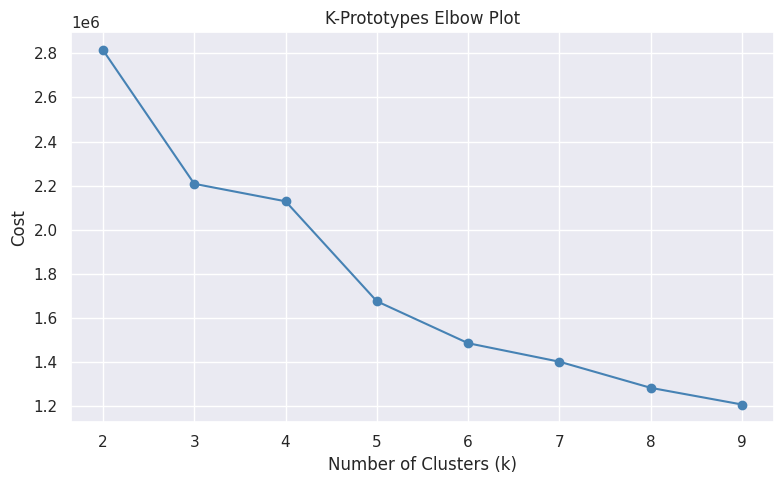

In [ ]:
# Sample for speed
X_sample = resample(X_cluster, n_samples=10000, random_state=42)

costs = []
k_range = range(2, 10)

for k in k_range:
    kproto = KPrototypes(n_clusters=k, random_state=42, n_init=3)
    kproto.fit(X_sample, categorical=categorical_indices)
    costs.append(kproto.cost_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, costs, marker='o', color='steelblue')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Cost')
plt.title('K-Prototypes Elbow Plot')
plt.tight_layout()
plt.show()

**The optimal number of clusters is 4**
- From k = 2 to k = 3 and k = 3 to k = 4, the lines decreases sharply.
- From k = 4 onwards, the line becomes steeper, which suggests the sign of optimization.
- If we use k > 4, while the cost may reduces, it takes considerable longer time to execute, which may result in costing more resources in the end.

In [ ]:
k = 4

kproto = KPrototypes(n_clusters=k, random_state=42, n_init=3)
clusters = kproto.fit_predict(X_cluster, categorical=categorical_indices)
clean_data['Cluster'] = clusters

We plot PCA 2D using numerical features only to see how the clusters are divided. We only use features that were shown to have strong correlations.

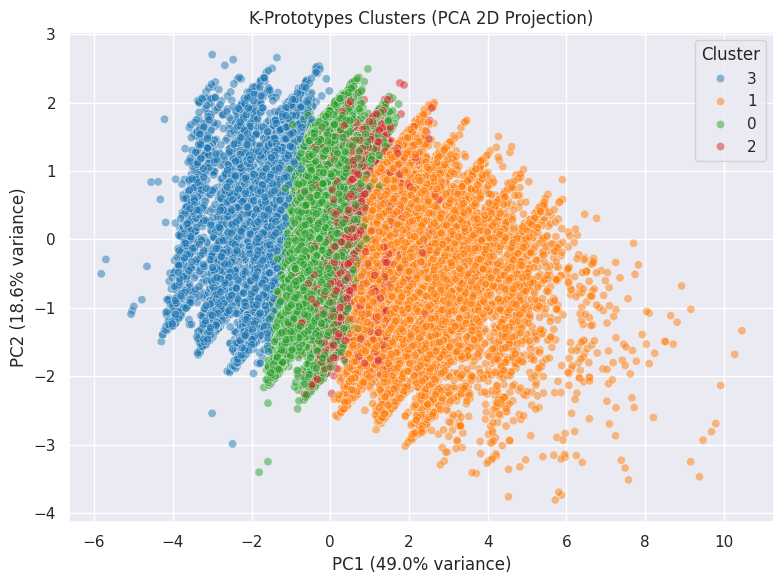

In [ ]:
numerical_features = ['age', 'BMI', 'ap_hi', 'ap_lo', 'pulse_press']

scaler = StandardScaler()
X_numerical_scaled = scaler.fit_transform(clean_data[numerical_features])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_numerical_scaled)

plt.figure(figsize=(8, 6))
sb.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
               hue=clean_data['Cluster'].astype(str),
               palette='tab10', alpha=0.5)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('K-Prototypes Clusters (PCA 2D Projection)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


This visualization does not give us much information so we have to use other ways.

## Information about the clusters

In [ ]:
cluster_profile = clean_data.groupby('Cluster')[cluster_features].mean().round(2)
print(cluster_profile)


           age    BMI   ap_hi  ap_lo  pulse_press  cholesterol  gluc  smoke  \
Cluster                                                                       
0        53.25  26.75  121.69  78.73        42.96         1.28  1.20   0.08   
1        55.06  29.24  149.34  89.70        59.64         1.57  1.30   0.10   
2        53.97  28.82  130.20  92.16        38.05         1.50  1.26   0.10   
3        50.56  25.73  106.69  70.12        36.57         1.23  1.16   0.08   

         alco  active  
Cluster                
0        0.05    0.80  
1        0.06    0.81  
2        0.07    0.80  
3        0.05    0.82  


## Information about the clusters visualized using heatmap

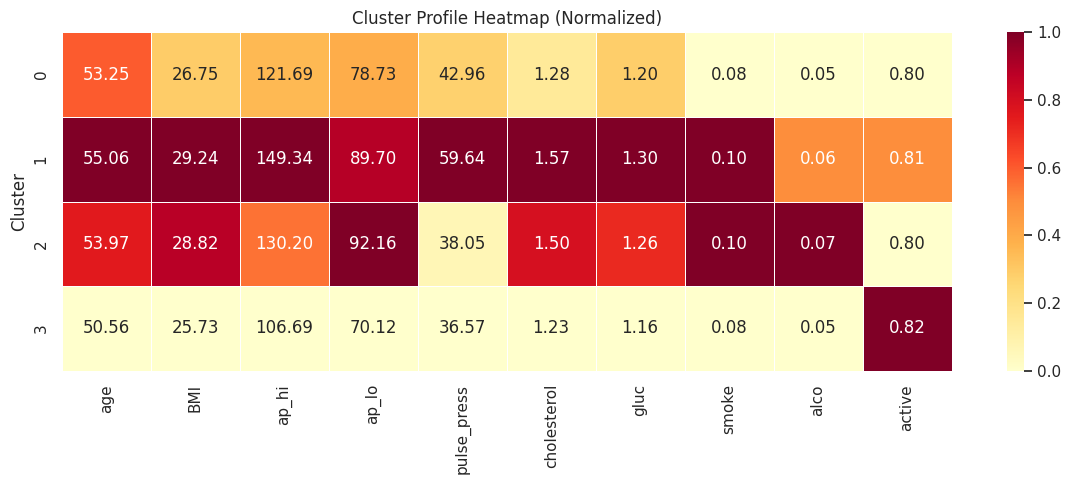

In [ ]:
scaler_viz = MinMaxScaler()
cluster_profile_normalized = pd.DataFrame(
    scaler_viz.fit_transform(cluster_profile),
    index=cluster_profile.index,
    columns=cluster_profile.columns
)

plt.figure(figsize=(12, 5))
sb.heatmap(cluster_profile_normalized, annot=cluster_profile.values,
           fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('Cluster Profile Heatmap (Normalized)')
plt.tight_layout()
plt.show()

## Visualization of features in each clusters
Only features that have strong correlations/ association strength and are representative are used.

/tmp/ipykernel_4457/1915067767.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=cluster_profile.index, y=cluster_profile[feature],
/tmp/ipykernel_4457/1915067767.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=cluster_profile.index, y=cluster_profile[feature],
/tmp/ipykernel_4457/1915067767.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=cluster_profile.index, y=cluster_profile[feature],
/tmp/ipykernel_4457/1915067767.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. 

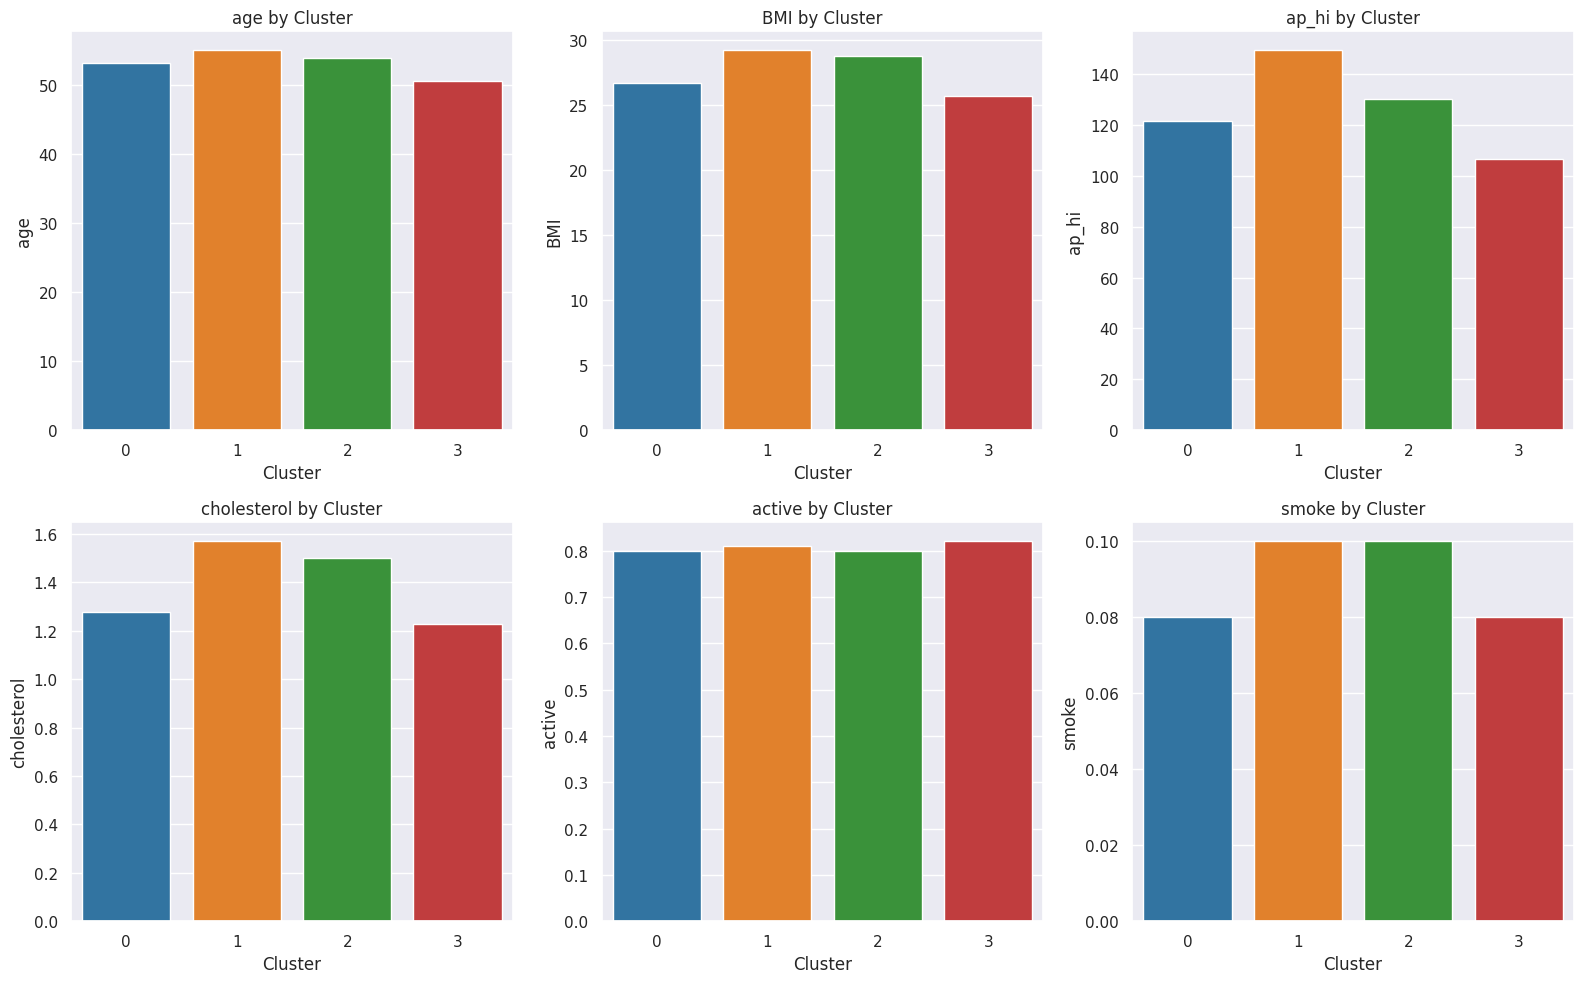

In [ ]:
# Bar charts
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
key_features = ['age', 'BMI', 'ap_hi', 'cholesterol', 'active', 'smoke']

for i, feature in enumerate(key_features):
    ax = axes[i//3, i%3]
    sb.barplot(x=cluster_profile.index, y=cluster_profile[feature],
               palette='tab10', ax=ax)
    ax.set_title(f'{feature} by Cluster')
    ax.set_xlabel('Cluster')
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

In [ ]:
cluster_cardio = clean_data.groupby('Cluster')['cardio'].mean() * 100
print(cluster_cardio.round(2).to_string())

Cluster
0    38.76
1    83.72
2    62.65
3    22.96


## Bar chart analysis

1. 4 distinct clusters

(a) **Cluster 0**
- Moderate age ($≈$52), low BMI ($≈$26), low ap_hi($≈$120), low cholesterol, active, low smoke, 38.76% CVD
- Middle Aged, Fit, Normal Blood Pressure, Low-Moderate Risk

(b) **Cluster 1**
- Moderate age ($≈$52), high BMI ($≈$28), very high ap_hi($≈$140), high cholesterol, active, smoker, 83.72% CVD
- Middle Aged, High Blood Pressure, High Risk

(c) **Cluster 2**
- Moderate age ($≈$53), high BMI ($≈$28), high ap_hi($≈$128), high cholesterol, active, smoker, 62.65% CVD
- Middle Aged, Evelated Blood Pressure, Moderate - High Risk

(d) **Cluster 3**
- Moderate age ($≈$50), low BMI ($≈$25), low ap_hi($≈$108), low cholesterol, active, low smoke, 22.96% CVD
- Middle Aged, Fit, Normal Blood Pressure,  Low Risk

2. Summary
- A huge spread in CVD rates (22.96% to 83.71%), the clustering found meaningful patients profiles.
- Blood pressure and cholesterol are the deciding factors in seperating high risk from low risk clusters.
- Life style factors are quite similar across clusters, but the risks are different, this aligns with the information from EDA that lifestyle factors are weak predictors.

## CVD Distribution within each Cluster using bar chart

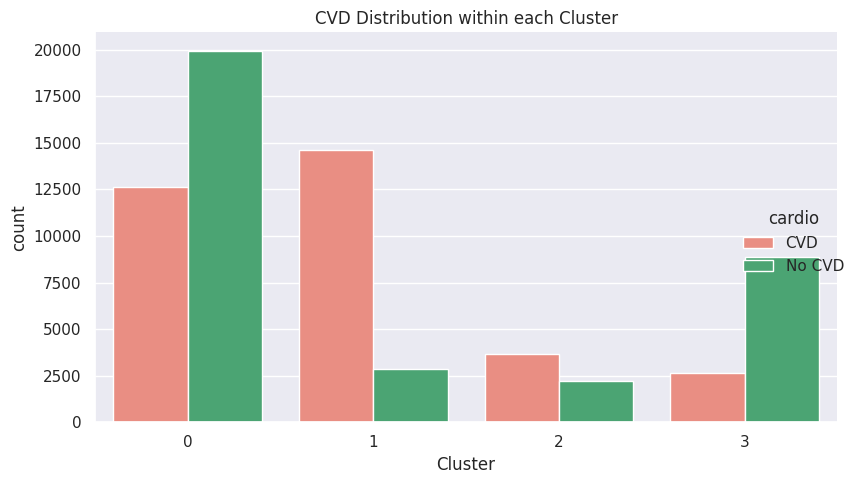

In [ ]:
plot_data2 = clean_data.copy()
plot_data2['cardio'] = plot_data2['cardio'].map({0: 'No CVD', 1: 'CVD'})

sb.catplot(data=plot_data2, x='Cluster', hue='cardio', kind='count',
           palette={'No CVD': 'mediumseagreen', 'CVD': 'salmon'},
           height=5, aspect=1.5)
plt.title('CVD Distribution within each Cluster')
plt.tight_layout()
plt.show()

# 5. Classification

## Random Forest, Logistic Regression and XGboost

## Importing libraries

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc

## Data preparation

**3 types of input data:**
1. clinical_features
2. lifestyle_features
3. all_features (clinical_features + lifestyle_features)

In [ ]:
clinical_features = ['age', 'gender', 'BMI', 'ap_hi', 'ap_lo',
                     'pulse_press', 'cholesterol', 'gluc']
lifestyle_features = ['smoke', 'alco', 'active']
all_features = clinical_features + lifestyle_features

# Define target
y = clean_data['cardio']


## Setting test_size

In [ ]:
X_clinical = clean_data[clinical_features]
X_lifestyle = clean_data[lifestyle_features]
X_all = clean_data[all_features]

X_clin_train, X_clin_test, y_clin_train, y_clin_test = train_test_split(
    X_clinical, y, test_size=0.2, random_state=42)

X_life_train, X_life_test, y_life_train, y_life_test = train_test_split(
    X_lifestyle, y, test_size=0.2, random_state=42)

X_all_train, X_all_test, y_all_train, y_all_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42)

scaler_clin = StandardScaler()
X_clin_train_scaled = scaler_clin.fit_transform(X_clin_train)
X_clin_test_scaled = scaler_clin.transform(X_clin_test)

scaler_life = StandardScaler()
X_life_train_scaled = scaler_life.fit_transform(X_life_train)
X_life_test_scaled = scaler_life.transform(X_life_test)

scaler_all = StandardScaler()
X_all_train_scaled = scaler_all.fit_transform(X_all_train)
X_all_test_scaled = scaler_all.transform(X_all_test)

## Fitting data into models

In [ ]:
# Random Forests
rf_clin = RandomForestClassifier(random_state=42, n_estimators=100)
rf_clin.fit(X_clin_train, y_clin_train)

rf_life = RandomForestClassifier(random_state=42, n_estimators=100)
rf_life.fit(X_life_train, y_life_train)

rf_all = RandomForestClassifier(random_state=42, n_estimators=100)
rf_all.fit(X_all_train, y_all_train)

# Logistic Regression
lr_clin = LogisticRegression(max_iter=1000, random_state=42)
lr_clin.fit(X_clin_train_scaled, y_clin_train)

lr_life = LogisticRegression(max_iter=1000, random_state=42)
lr_life.fit(X_life_train_scaled, y_life_train)

lr_all = LogisticRegression(max_iter=1000, random_state=42)
lr_all.fit(X_all_train_scaled, y_all_train)

#XGBoost
xgb_clin = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clin.fit(X_clin_train, y_clin_train)

xgb_life = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_life.fit(X_life_train, y_life_train)

xgb_all = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_all.fit(X_all_train, y_all_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:00:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:00:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:00:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

## Printing out accuracy and ROC scores


In [ ]:
results = pd.DataFrame({
    'Feature Set': ['Clinical Only', 'Lifestyle Only', 'All Features'],

    'Random Forest': [
        accuracy_score(y_clin_test, rf_clin.predict(X_clin_test)),
        accuracy_score(y_life_test, rf_life.predict(X_life_test)),
        accuracy_score(y_all_test, rf_all.predict(X_all_test))
    ],

    'Logistic Regression': [
        accuracy_score(y_clin_test, lr_clin.predict(X_clin_test_scaled)),
        accuracy_score(y_life_test, lr_life.predict(X_life_test_scaled)),
        accuracy_score(y_all_test, lr_all.predict(X_all_test_scaled))
    ],

    'XGBoost': [
        accuracy_score(y_clin_test, xgb_clin.predict(X_clin_test)),
        accuracy_score(y_life_test, xgb_life.predict(X_life_test)),
        accuracy_score(y_all_test, xgb_all.predict(X_all_test))
    ]
})

print("accuracy Results ")
print(results.to_string(float_format='%.4f', index=False))

accuracy Results 
   Feature Set  Random Forest  Logistic Regression  XGBoost
 Clinical Only         0.7033               0.7269   0.7322
Lifestyle Only         0.5152               0.5138   0.5152
  All Features         0.7045               0.7291   0.7348


### Analysis
- Clinical data proves to be better predictor compared to lifestyle data in both models.
- XGBoost is the most effective model from the 3 models in predicitng the CDV risk with the same dataset.
- When given the whole dataset, the accuracy scores do not change much compaed to when only using clinical data.
- This proves that lifestyle data does not contribute much in predicting 'cardio'.

In [ ]:
roc_results = pd.DataFrame({
    'Feature Set': ['Clinical Only', 'Lifestyle Only', 'All Features'],

    'Random Forest': [
        roc_auc_score(y_clin_test, rf_clin.predict_proba(X_clin_test)[:, 1]),
        roc_auc_score(y_life_test, rf_life.predict_proba(X_life_test)[:, 1]),
        roc_auc_score(y_all_test, rf_all.predict_proba(X_all_test)[:, 1])
    ],

    'Logistic Regression': [
        roc_auc_score(y_clin_test, lr_clin.predict_proba(X_clin_test_scaled)[:, 1]),
        roc_auc_score(y_life_test, lr_life.predict_proba(X_life_test_scaled)[:, 1]),
        roc_auc_score(y_all_test, lr_all.predict_proba(X_all_test_scaled)[:, 1])
    ],

    'XGBoost': [
        roc_auc_score(y_clin_test, xgb_clin.predict_proba(X_clin_test)[:, 1]),
        roc_auc_score(y_life_test, xgb_life.predict_proba(X_life_test)[:, 1]),
        roc_auc_score(y_all_test, xgb_all.predict_proba(X_all_test)[:, 1])
    ]
})

print("ROC AUC Results ")
print(roc_results.to_string(float_format='%.4f', index=False))

ROC AUC Results 
   Feature Set  Random Forest  Logistic Regression  XGBoost
 Clinical Only         0.7584               0.7923   0.7941
Lifestyle Only         0.5165               0.5138   0.5165
  All Features         0.7620               0.7937   0.7966


## Confusion Matrices

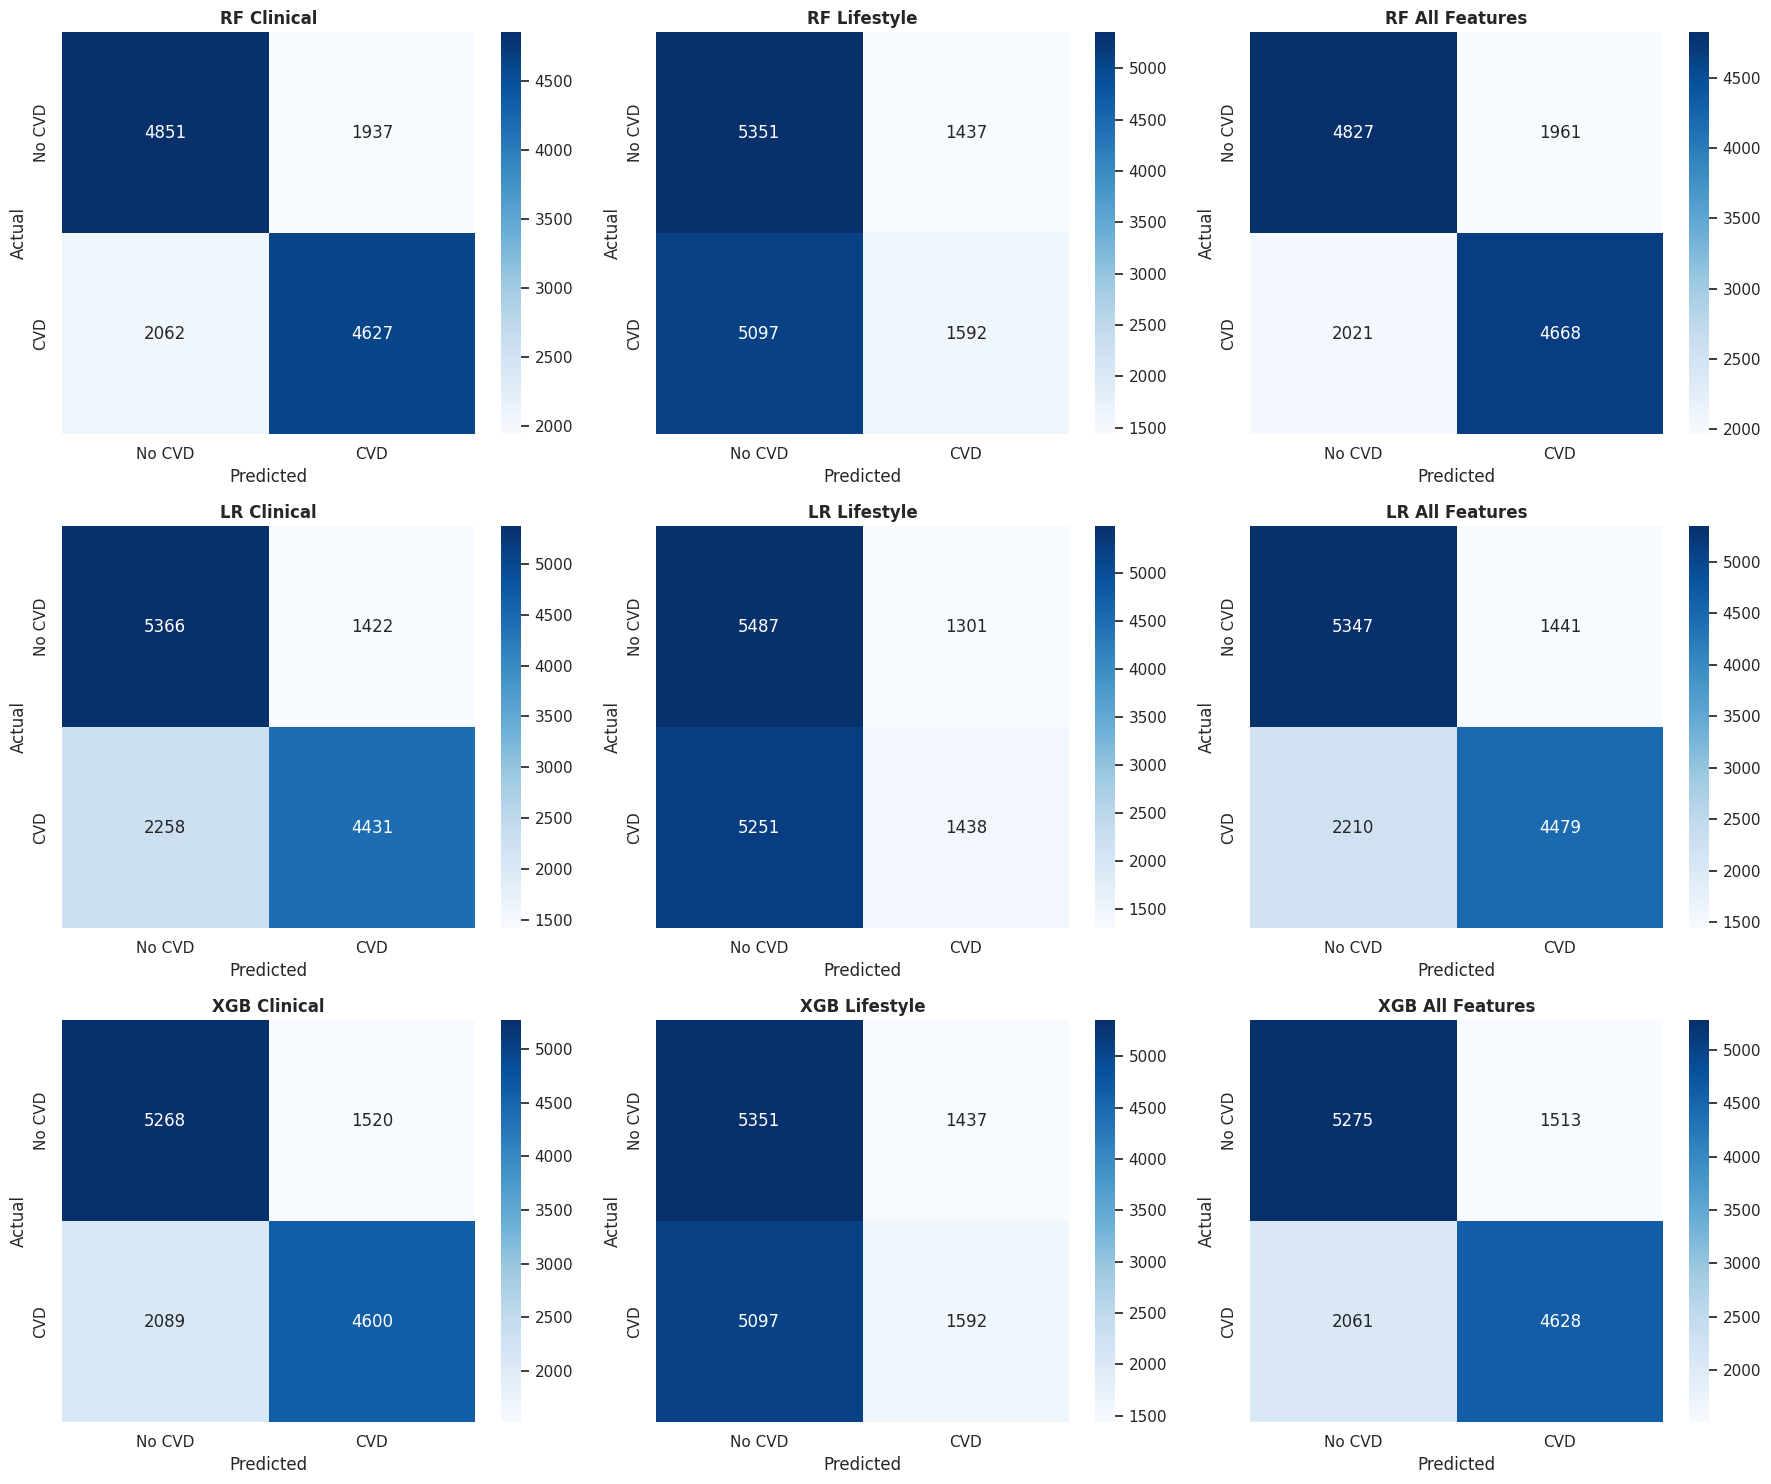

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

models = [
    rf_clin, rf_life, rf_all,
    lr_clin, lr_life, lr_all,
    xgb_clin, xgb_life, xgb_all
]

X_tests = [
    X_clin_test, X_life_test, X_all_test,
    X_clin_test_scaled, X_life_test_scaled, X_all_test_scaled,
    X_clin_test, X_life_test, X_all_test
]

y_tests = [
    y_clin_test, y_life_test, y_all_test,
    y_clin_test, y_life_test, y_all_test,
    y_clin_test, y_life_test, y_all_test
]

titles = [
    'RF Clinical', 'RF Lifestyle', 'RF All Features',
    'LR Clinical', 'LR Lifestyle', 'LR All Features',
    'XGB Clinical', 'XGB Lifestyle', 'XGB All Features'
]

for i, (model, X_test, y_test, title) in enumerate(zip(models, X_tests, y_tests, titles)):
    cm = confusion_matrix(y_test, model.predict(X_test))

    ax = axes[i // 3, i % 3]

    sb.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
               xticklabels=['No CVD', 'CVD'],
               yticklabels=['No CVD', 'CVD'])

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Importance of every features for each model

/tmp/ipykernel_4457/4180107767.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=rf_importance_df, x='Importance', y='Feature',
/tmp/ipykernel_4457/4180107767.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=lr_importance_df, x='Importance', y='Feature',
/tmp/ipykernel_4457/4180107767.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=xgb_importance_df, x='Importance', y='Feature',


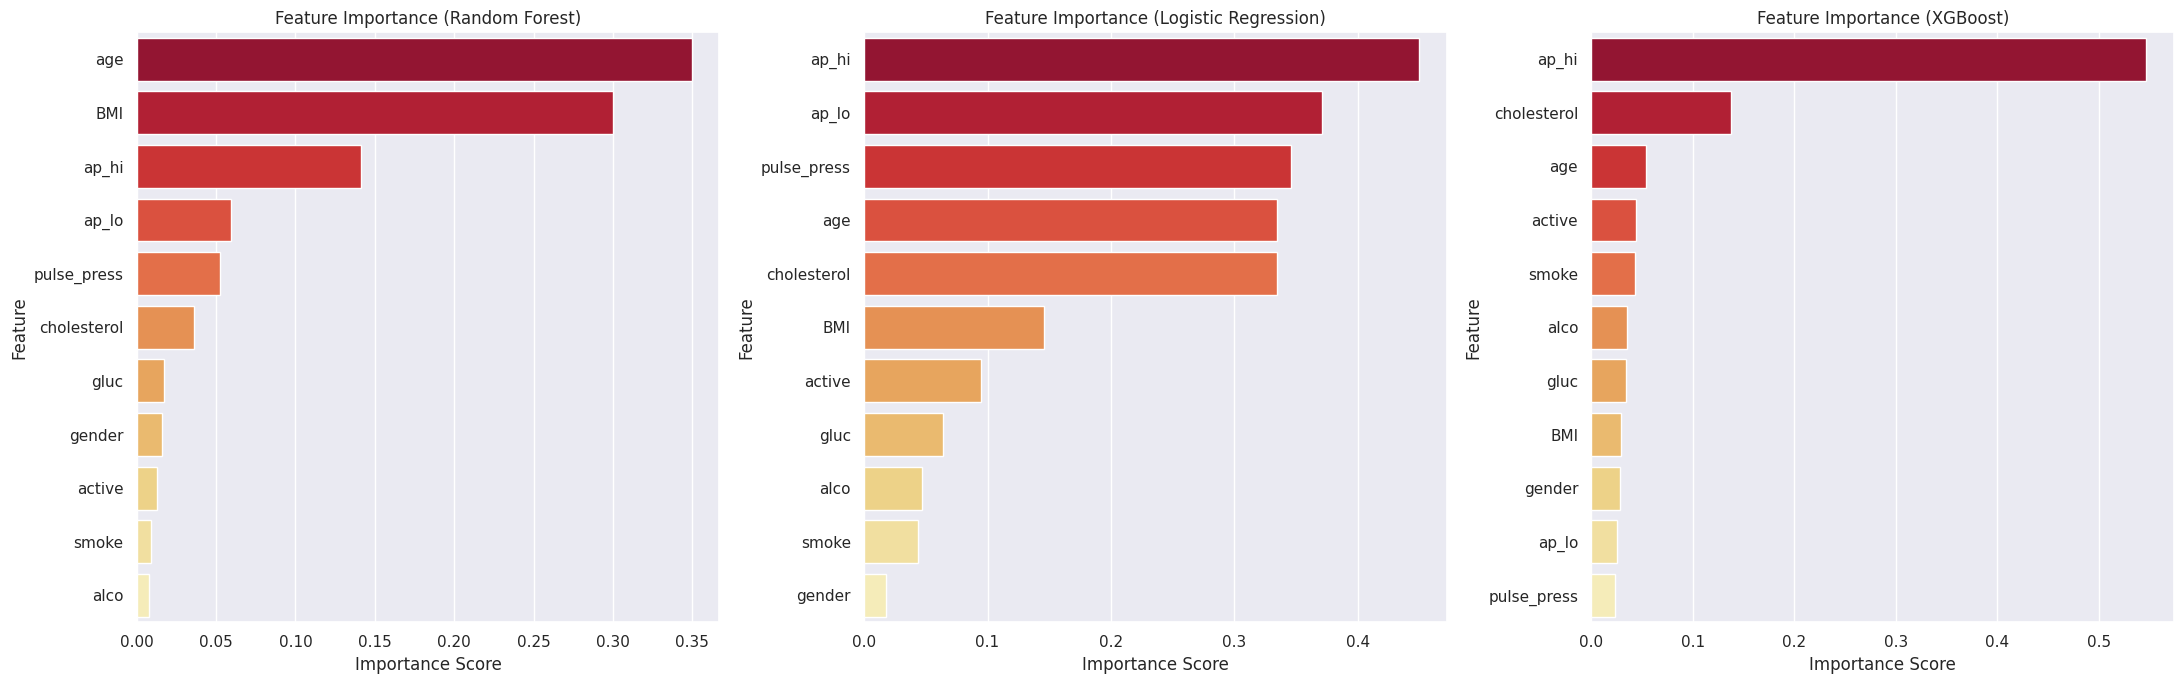

Random Forest Feature Importance:
    Feature  Importance
        age      0.3495
        BMI      0.2999
      ap_hi      0.1412
      ap_lo      0.0594
pulse_press      0.0522
cholesterol      0.0359
       gluc      0.0170
     gender      0.0159
     active      0.0126
      smoke      0.0088
       alco      0.0076

Logistic Regression Feature Importance:
    Feature  Importance
      ap_hi      0.4495
      ap_lo      0.3708
pulse_press      0.3460
        age      0.3348
cholesterol      0.3342
        BMI      0.1457
     active      0.0945
       gluc      0.0640
       alco      0.0467
      smoke      0.0433
     gender      0.0178

XGBoost Feature Importance:
    Feature  Importance
      ap_hi      0.5469
cholesterol      0.1377
        age      0.0538
     active      0.0436
      smoke      0.0433
       alco      0.0346
       gluc      0.0339
        BMI      0.0292
     gender      0.0282
      ap_lo      0.0252
pulse_press      0.0236


In [ ]:
# Random Forest
rf_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': rf_all.feature_importances_
}).sort_values('Importance', ascending=False)

# XGBoost
xgb_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': xgb_all.feature_importances_
}).sort_values('Importance', ascending=False)

# Logistic Regression
lr_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': np.abs(lr_all.coef_[0])
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Plot Random Forest
sb.barplot(data=rf_importance_df, x='Importance', y='Feature',
           palette='YlOrRd_r', ax=axes[0])
axes[0].set_title('Feature Importance (Random Forest)')
axes[0].set_xlabel('Importance Score')

# Plot Logistic Regression
sb.barplot(data=lr_importance_df, x='Importance', y='Feature',
           palette='YlOrRd_r', ax=axes[1])
axes[1].set_title('Feature Importance (Logistic Regression)')
axes[1].set_xlabel('Importance Score')

# Plot XGBoost
sb.barplot(data=xgb_importance_df, x='Importance', y='Feature',
           palette='YlOrRd_r', ax=axes[2])
axes[2].set_title('Feature Importance (XGBoost)')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

print("Random Forest Feature Importance:")
print(rf_importance_df.to_string(float_format='%.4f', index=False))

print("\nLogistic Regression Feature Importance:")
print(lr_importance_df.to_string(float_format='%.4f', index=False))

print("\nXGBoost Feature Importance:")
print(xgb_importance_df.to_string(float_format='%.4f', index=False))

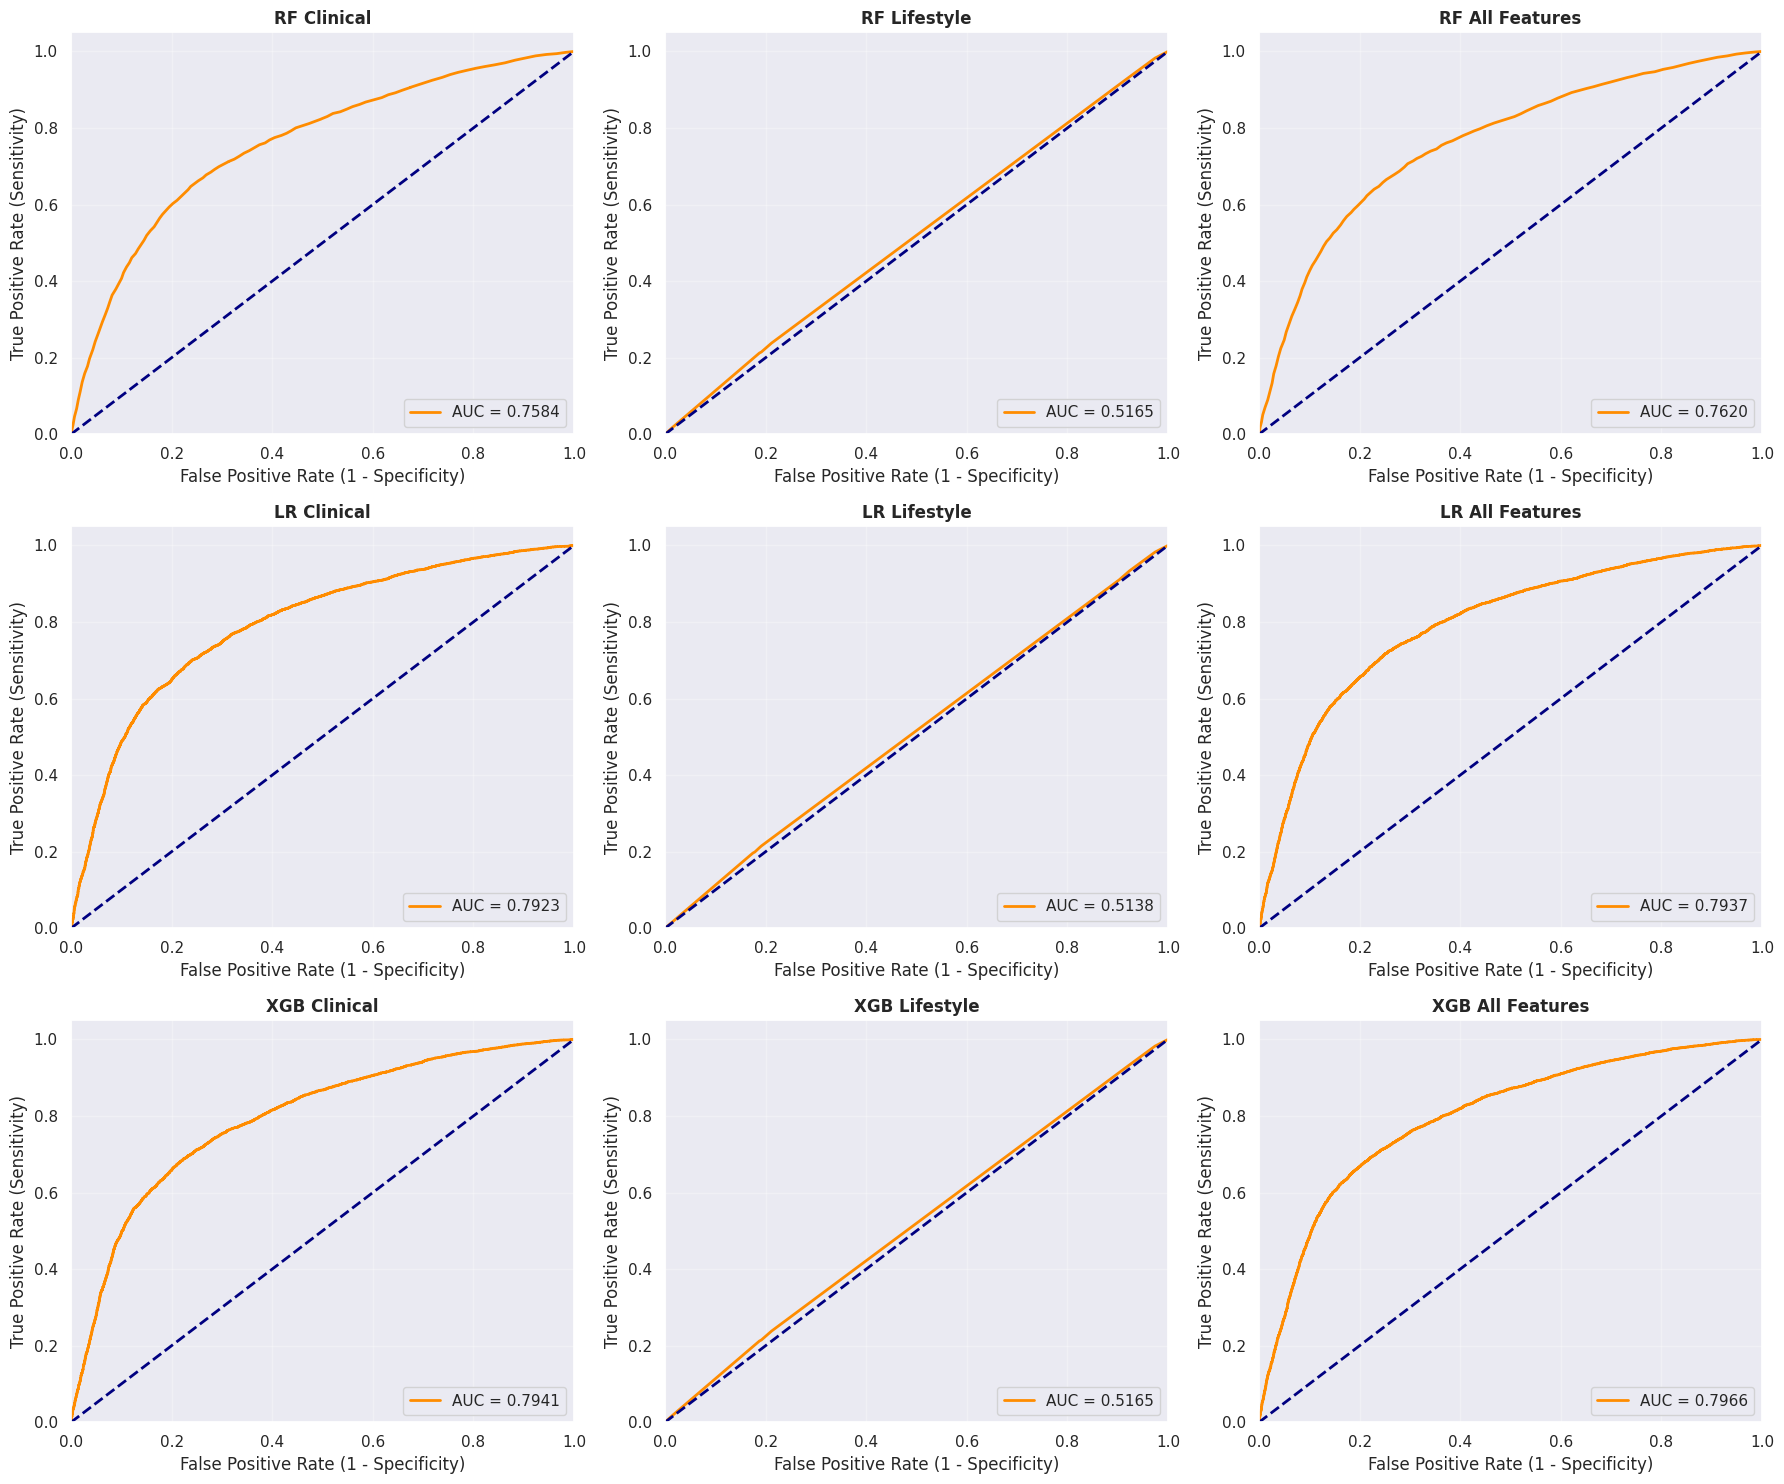

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

models = [
    rf_clin, rf_life, rf_all,
    lr_clin, lr_life, lr_all,
    xgb_clin, xgb_life, xgb_all
]

X_tests = [
    X_clin_test, X_life_test, X_all_test,
    X_clin_test_scaled, X_life_test_scaled, X_all_test_scaled,
    X_clin_test, X_life_test, X_all_test
]

y_tests = [
    y_clin_test, y_life_test, y_all_test,
    y_clin_test, y_life_test, y_all_test,
    y_clin_test, y_life_test, y_all_test
]

titles = [
    'RF Clinical', 'RF Lifestyle', 'RF All Features',
    'LR Clinical', 'LR Lifestyle', 'LR All Features',
    'XGB Clinical', 'XGB Lifestyle', 'XGB All Features'
]

for i, (model, X_test, y_test, title) in enumerate(zip(models, X_tests, y_tests, titles)):
    y_probs = model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    ax = axes[i // 3, i % 3]

    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')

    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate (1 - Specificity)')
    ax.set_ylabel('True Positive Rate (Sensitivity)')
    ax.set_title(title, fontweight='bold')
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Analysis
- All models point out that clinical data is much more important in predicting CDV risk, further reinforcing our claim.
- In Logistic Regression and XGBoost models shows that ap_hi (systolic blood pressure) is the most important features in predicting CVD risk While in Random forest, age is the most important features
- From the ROC curve, XGBoost is the most robust and capable of capturing subtle patterns.
- From ROC curve, we can also see the most striking takeaway is that our models are relying almost entirely on Clinical data, while the Lifestyle data is currently providing almost zero predictive value.

#6. Conlusion

1. Clinical data is more important than lifesyle data in predicting CDV risk
- In real life, cardiovascular disease is closely related to age and blood pressure so the result is sensible.
- Counterintuitively, such bad habits like smoking or alcohol do not have so many effects on whether a person has cardiovascular disease or not.

2. What does it mean to doctors and patients
- The risk of having a CDV can be predicted using data like their age, blood pressure, this method is reliable.
- If a patient is more than 50 years old, have high blood pressure, their glucose and cholesterol levels are high, there is a really high chance that they have CDV.

3. Areas to improve
- There is significant less amount of lifestyle data compared to clinical data, so in fact, a patient's habits can still have certain effects on whether they have CDV or not.
- To further investigate this, the dataset needs more subjective data.
- When using both lifestyle features and clinical features, the best accuracy score is around 0.7, to improve this, we need to implement more precise models and other medical data.

## **CVD Risk Prediction Tool**

In [ ]:
def predict_cvd_risk(model):
    print(" Cardiovascular Disease Risk Assessment ")
    print("Enter the following values:")

    # Input values from the user
    gender = int(input("Gender (1: male, 2: female): "))
    while gender not in [1,2] :
        gender = int(input("Invalid input. Please enter a valid gender (1 : male, 2 : female): "))

    age = int(input("Age: "))
    while age < 0 :
        age = int(input("Invalid input. Please enter a valid age: "))

    height = int(input("Height(cm) : "))
    while gender < 0:
        height = int(input("Invalid input. Please enter a valid height: "))

    weight = float(input("Weight(kg) : "))
    while gender < 0:
        weight = float(input("Invalid input. Please enter a valid weight: "))

    ap_hi = int(input("Systolic Blood Pressure: "))
    while ap_hi < 40 or ap_hi > 300:
        ap_hi = int(input("Invalid input. Please enter a valid Systolic Blood Pressure: "))

    ap_lo = int(input("Diastolic Blood Pressure: "))
    while ap_lo < 20 or ap_lo > 200:
        ap_lo = int(input("Invalid input. Please enter a valid Diastolic Blood Pressure: "))

    cholesterol = int(input("Cholesterol level (1: normal,  2: above normal, 3: well above normal): "))
    while cholesterol not in [1,2,3]:
        cholesterol = int(input("Invalid input. Please enter a valid cholesterol level (1: normal, 2: above normal, 3: well above normal): "))

    gluc = int(input("Glucose level (1: normal, 2: above normal, 3: well above normal): "))
    while gluc not in [1,2,3]:
        gluc = int(input("Invalid input. Please enter a valid glucose level (1: normal, 2: above normal, 3: well above normal): "))

    smoke = int(input("Do you smoke? (0: does not smoke, 1: smoke): "))
    while smoke not in [0,1]:
        smoke = int(input("Invalid input. Please enter a valid response for smoking (0: does not smoke, 1: smoke): "))

    alco = int(input("Do you drink alcohol? (0: does not drink, 1: drinks): "))
    while alco not in [0,1]:
        alco = int(input("Invalid input. Please enter a valid response for alcohol (0: does not drink, 1: drinks): "))

    active = int(input("Are you active? (0: not active,  1: active): "))
    while active not in [0,1]:
        active = int(input("Invalid input. Please enter a valid response for activity (0: not active,  1: active): "))

    bmi = weight / (height / 100) ** 2

    pulse_press = ap_hi - ap_lo

    # Create a DataFrame with the exact feature names used during training
    user_data = pd.DataFrame([[age, gender, bmi, ap_hi, ap_lo, pulse_press, cholesterol, gluc, smoke, alco, active]],
                columns=['age', 'gender', 'BMI', 'ap_hi', 'ap_lo', 'pulse_press', 'cholesterol', 'gluc', 'smoke', 'alco', 'active'])

    # Get probability of class 1 (Cardio = Yes)
    probability = model.predict_proba(user_data)[0][1]

    # Format and display results
    percentage = probability * 100
    print("\n--- Result ---")
    print(f"Likelihood of Cardiovascular Disease: {percentage:.2f}%")

    if percentage <= 40:
        status = "LOW RISK"
        advice = "Maintain a healthy lifestyle and continue regular check-ups."
    elif 40 < percentage <= 70:
        status = "MODERATE RISK"
        advice = "Lifestyle modifications are suggested. Monitor blood pressure closely."
    else:
        status = "HIGH RISK"
        advice = "Strongly recommended to consult a healthcare professional for a diagnostic workup."

    print(f"Status: {status}")
    print(f"Advice: {advice}")

# To run the function:
predict_cvd_risk(xgb_all)